### Imports ###

In [4]:
%reload_ext autoreload
%autoreload 2

import time
import corner
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

import numpy as np

import jax
import jax.numpy as jnp
import blackjax
from blackjax.ns.utils import finalise, log_weights
print(jax.devices())

from data import get_data_orbit
from prior import prior_dists_orbit, logprior_orbit, sample_from_priors_orbit
from loglikelihood import loglikelihood_stream, loglikelihood_orbit
from model import jax_stream_model, jax_stream_orbit

[CpuDevice(id=0)]


In [6]:
from data import get_data_stream

q_true = 0.8
seed   = 42
sigma  = 1
nlive  = 1000
ndim   = 15
queue_size = 100
PATH_SAVE = f'.'

dict_data = get_data_stream(q_true, seed, sigma)

In [7]:
with open('./dns_results.pkl', 'rb') as f:
    data = pickle.load(f)

In [9]:
data['samps'].shape

(47445, 13)

In [11]:
dict_data['samps'] = data['samps']

ValueError: Provided figure has 169 axes, but data has dimensions K=14

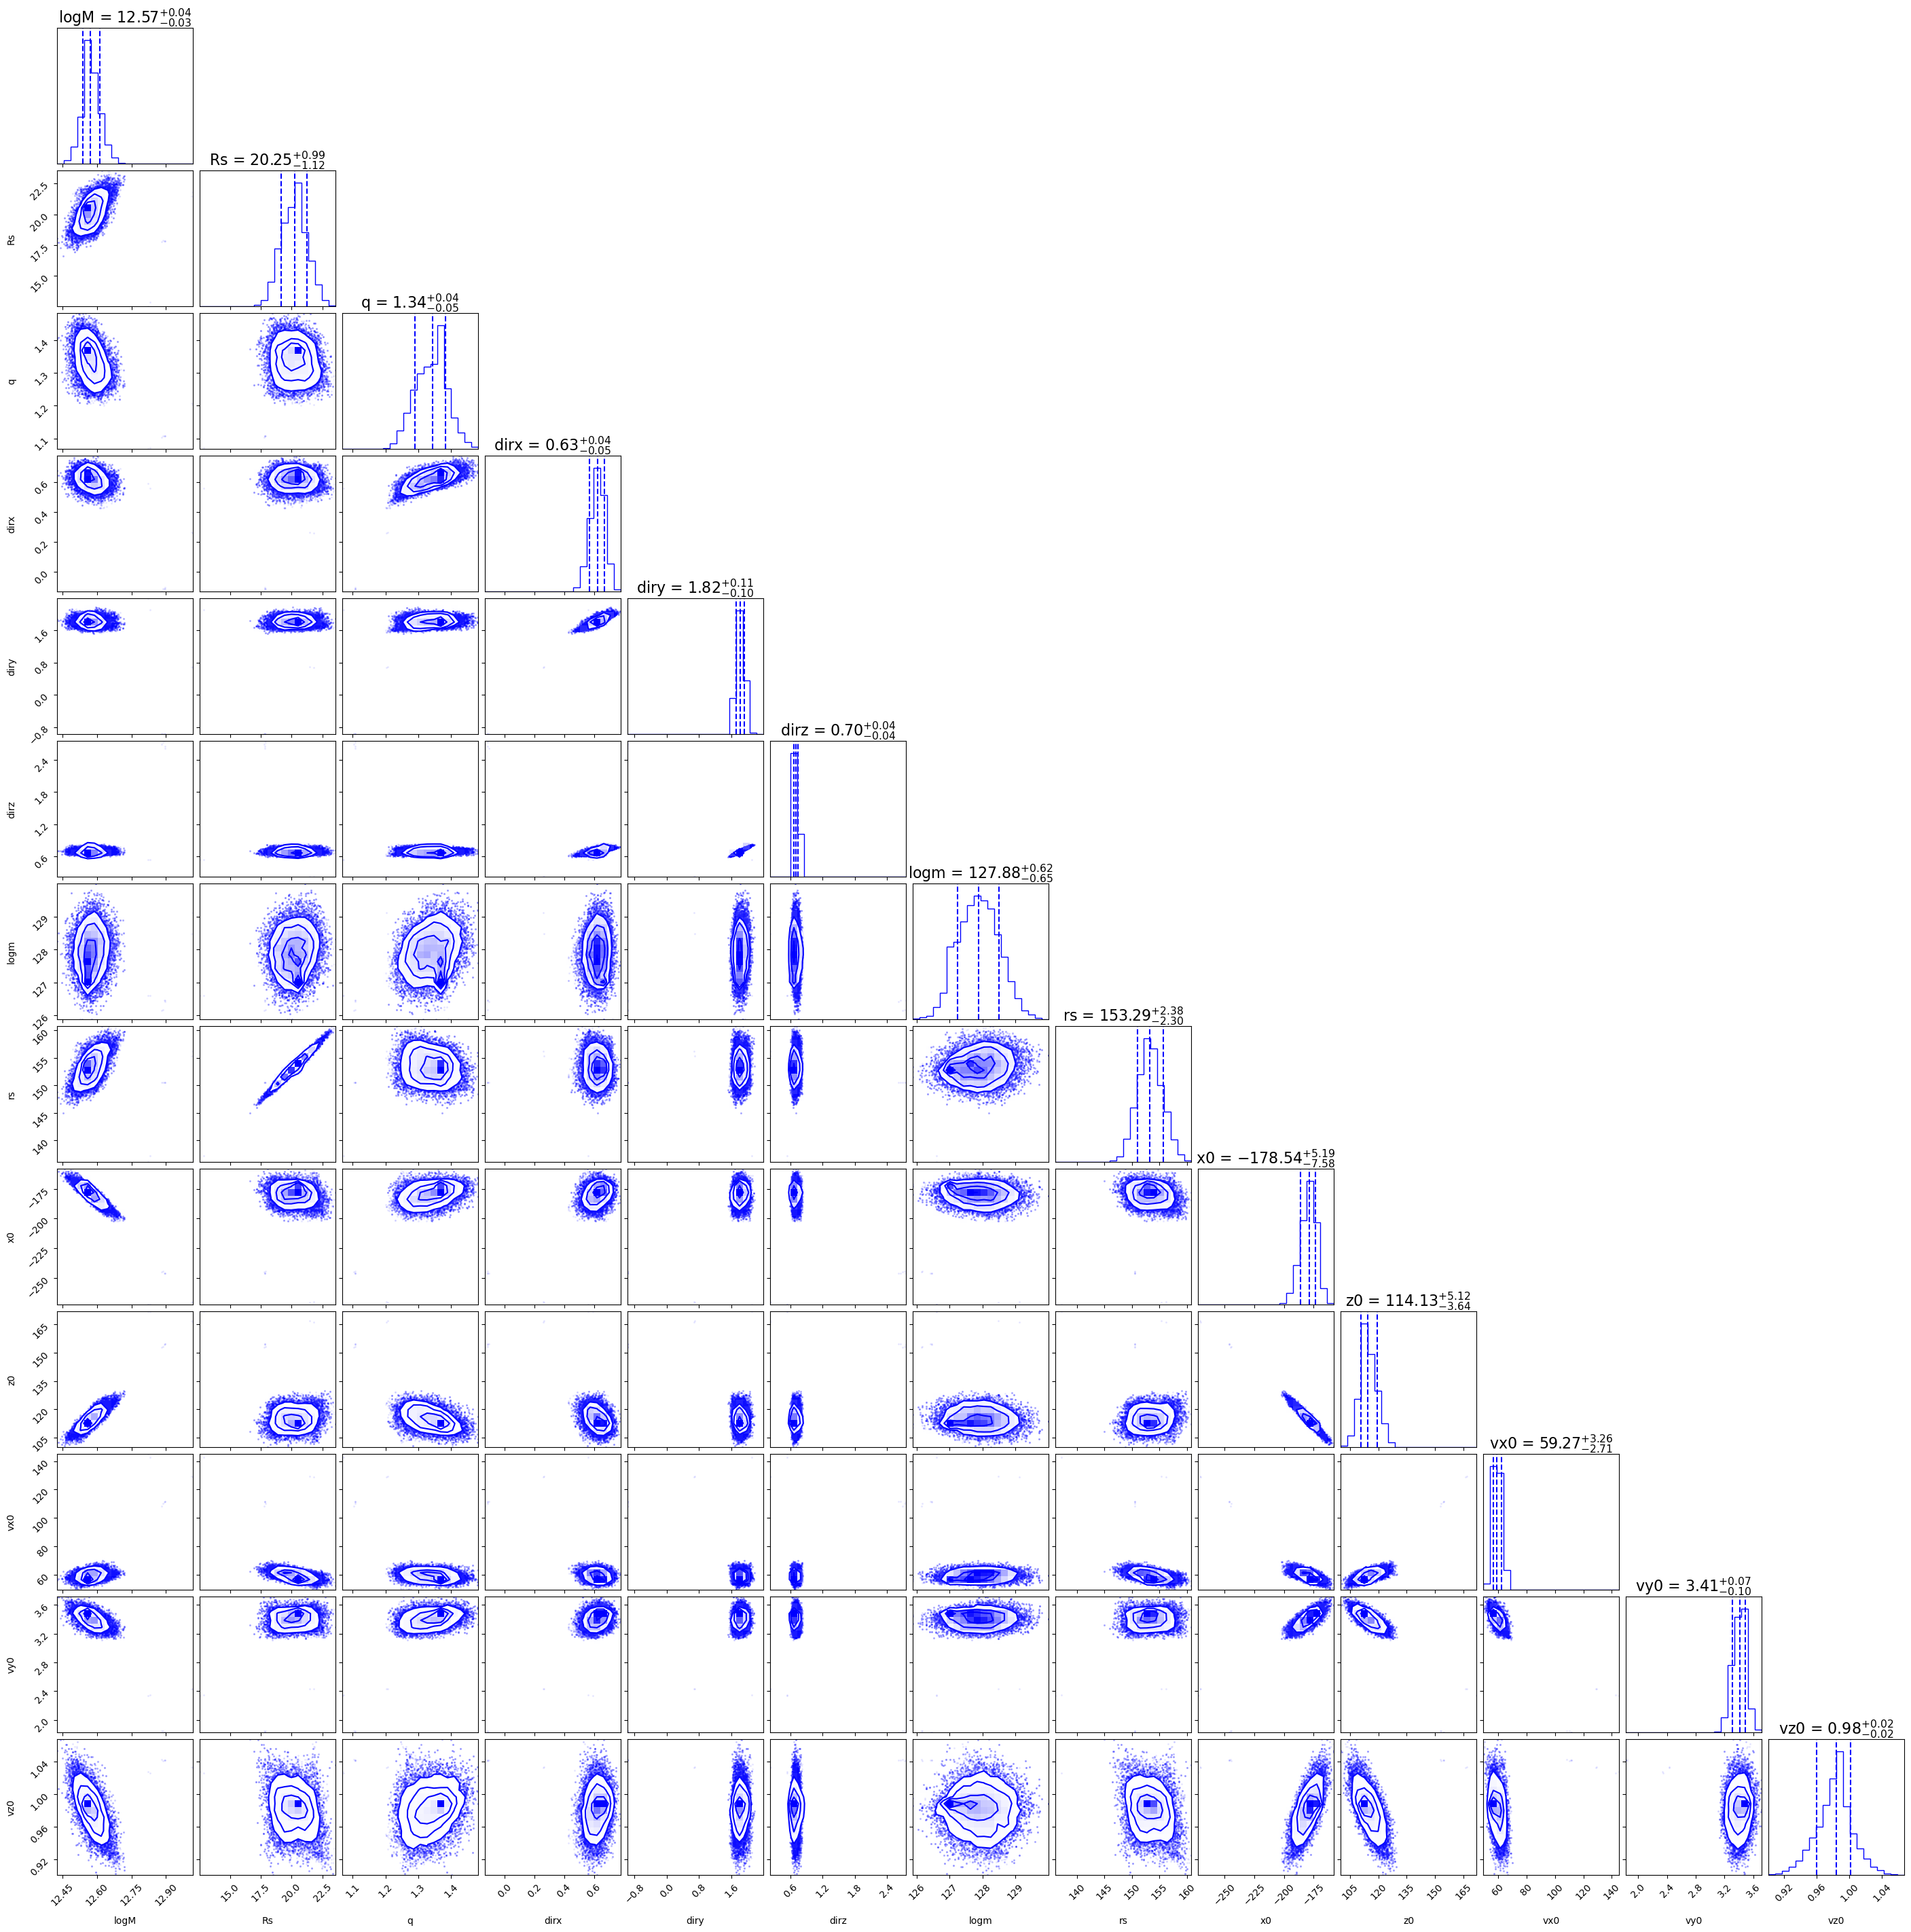

In [ ]:
labels = ['logM', 'Rs', 'q', 'dirx', 'diry', 'dirz', 'logm', 'rs', 'x0', 'z0', 'vx0', 'vy0', 'vz0', 'time', 'alpha']
# ground_truth = np.concatenate( [data['params'], [1]])
figure = corner.corner(data['samps'], 
            labels=labels,
            color='blue',
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True, 
            title_kwargs={"fontsize": 16},
            truths=dict_data['params'], 
            truth_color='red')
# plt.savefig(f'plots/corner_stream.pdf')
# plt.savefig(f'plots/corner_q0.8_sig1_seed42_nlive100.pdf')

### Get the Data ###

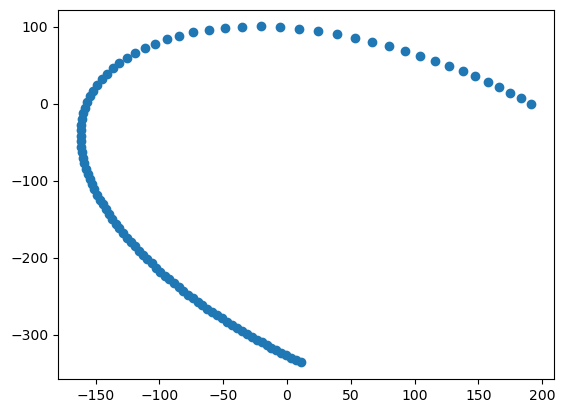

In [2]:
# Get data
q_true = 0.8
seed   = 42
sigma  = 1
n_live = 10
PATH_SAVE = f'./'

dict_data = get_data_orbit(q_true, seed, sigma)
plt.scatter(dict_data['x_stream'], dict_data['y_stream'])

In [3]:
rng_key = jax.random.PRNGKey(0)
rng_key, init_key = jax.random.split(rng_key)

initial_particles = sample_from_priors_orbit(init_key, n_live)

In [4]:
initial_particles.shape

(10, 13)

In [42]:
logl = jax.vmap(lambda p: loglikelihood_orbit(p, dict_data))(initial_particles)

In [45]:
logM, Rs, q, dirx, diry, dirz, x0, z0, vx0, vy0, vz0, time, alpha = initial_particles[1]
dirz = jnp.abs(dirz)
x0   = jnp.abs(x0)
z0   = jnp.abs(z0)
vy0  = jnp.abs(vy0)

y0 = 0.

theta_stream, x_stream, y_stream, vz_stream, r_meds, w_meds, x_meds, y_meds, vz_meds = jax_stream_orbit(logM, Rs, q, dirx, diry, dirz, x0, y0, z0, vx0, vy0, vz0, time, alpha)

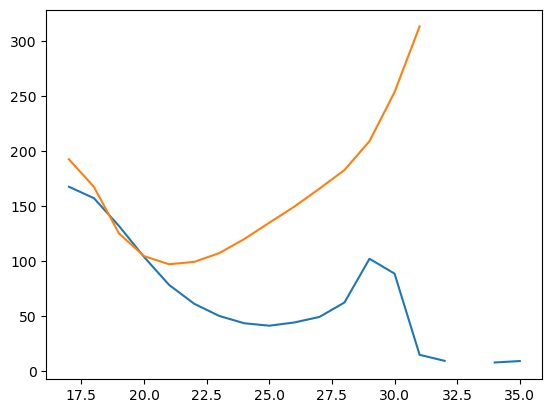

In [46]:
plt.plot(r_meds)
plt.plot(dict_data['r_data'])

In [50]:
jnp.where(jnp.isfinite(logl))[0]

Array([1], dtype=int32)

In [47]:
mask = ~jnp.isnan(dict_data['r_data'])

# Count how many predictions are bad
nan_mask = jnp.isnan(jnp.where(mask, r_meds, 0.0))
n_bad = jnp.sum(nan_mask)

In [48]:
n_bad

Array(0, dtype=int32)

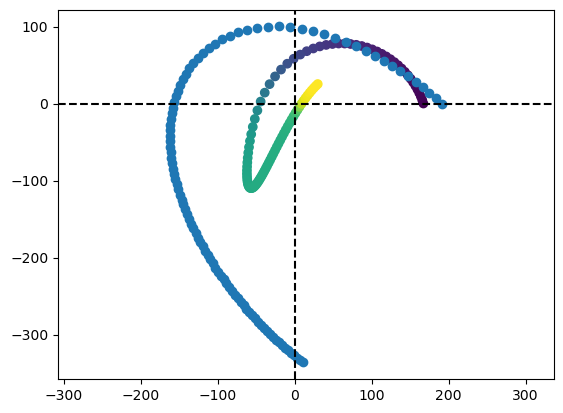

In [49]:
plt.scatter(x_stream, y_stream, c=theta_stream)
plt.scatter(dict_data['x_stream'], dict_data['y_stream'])
plt.axis('equal')
plt.axvline(0, color='k', ls='--')
plt.axhline(0, color='k', ls='--')

### Load the Samples ###

In [ ]:
samps_100 = np.load('samples/samps_q0.8_sig1_seed42_nlive100.npy')
samps_500 = np.load('samples/samps_q0.8_sig1_seed42_nlive500.npy')

### Plot the Posteriors ###

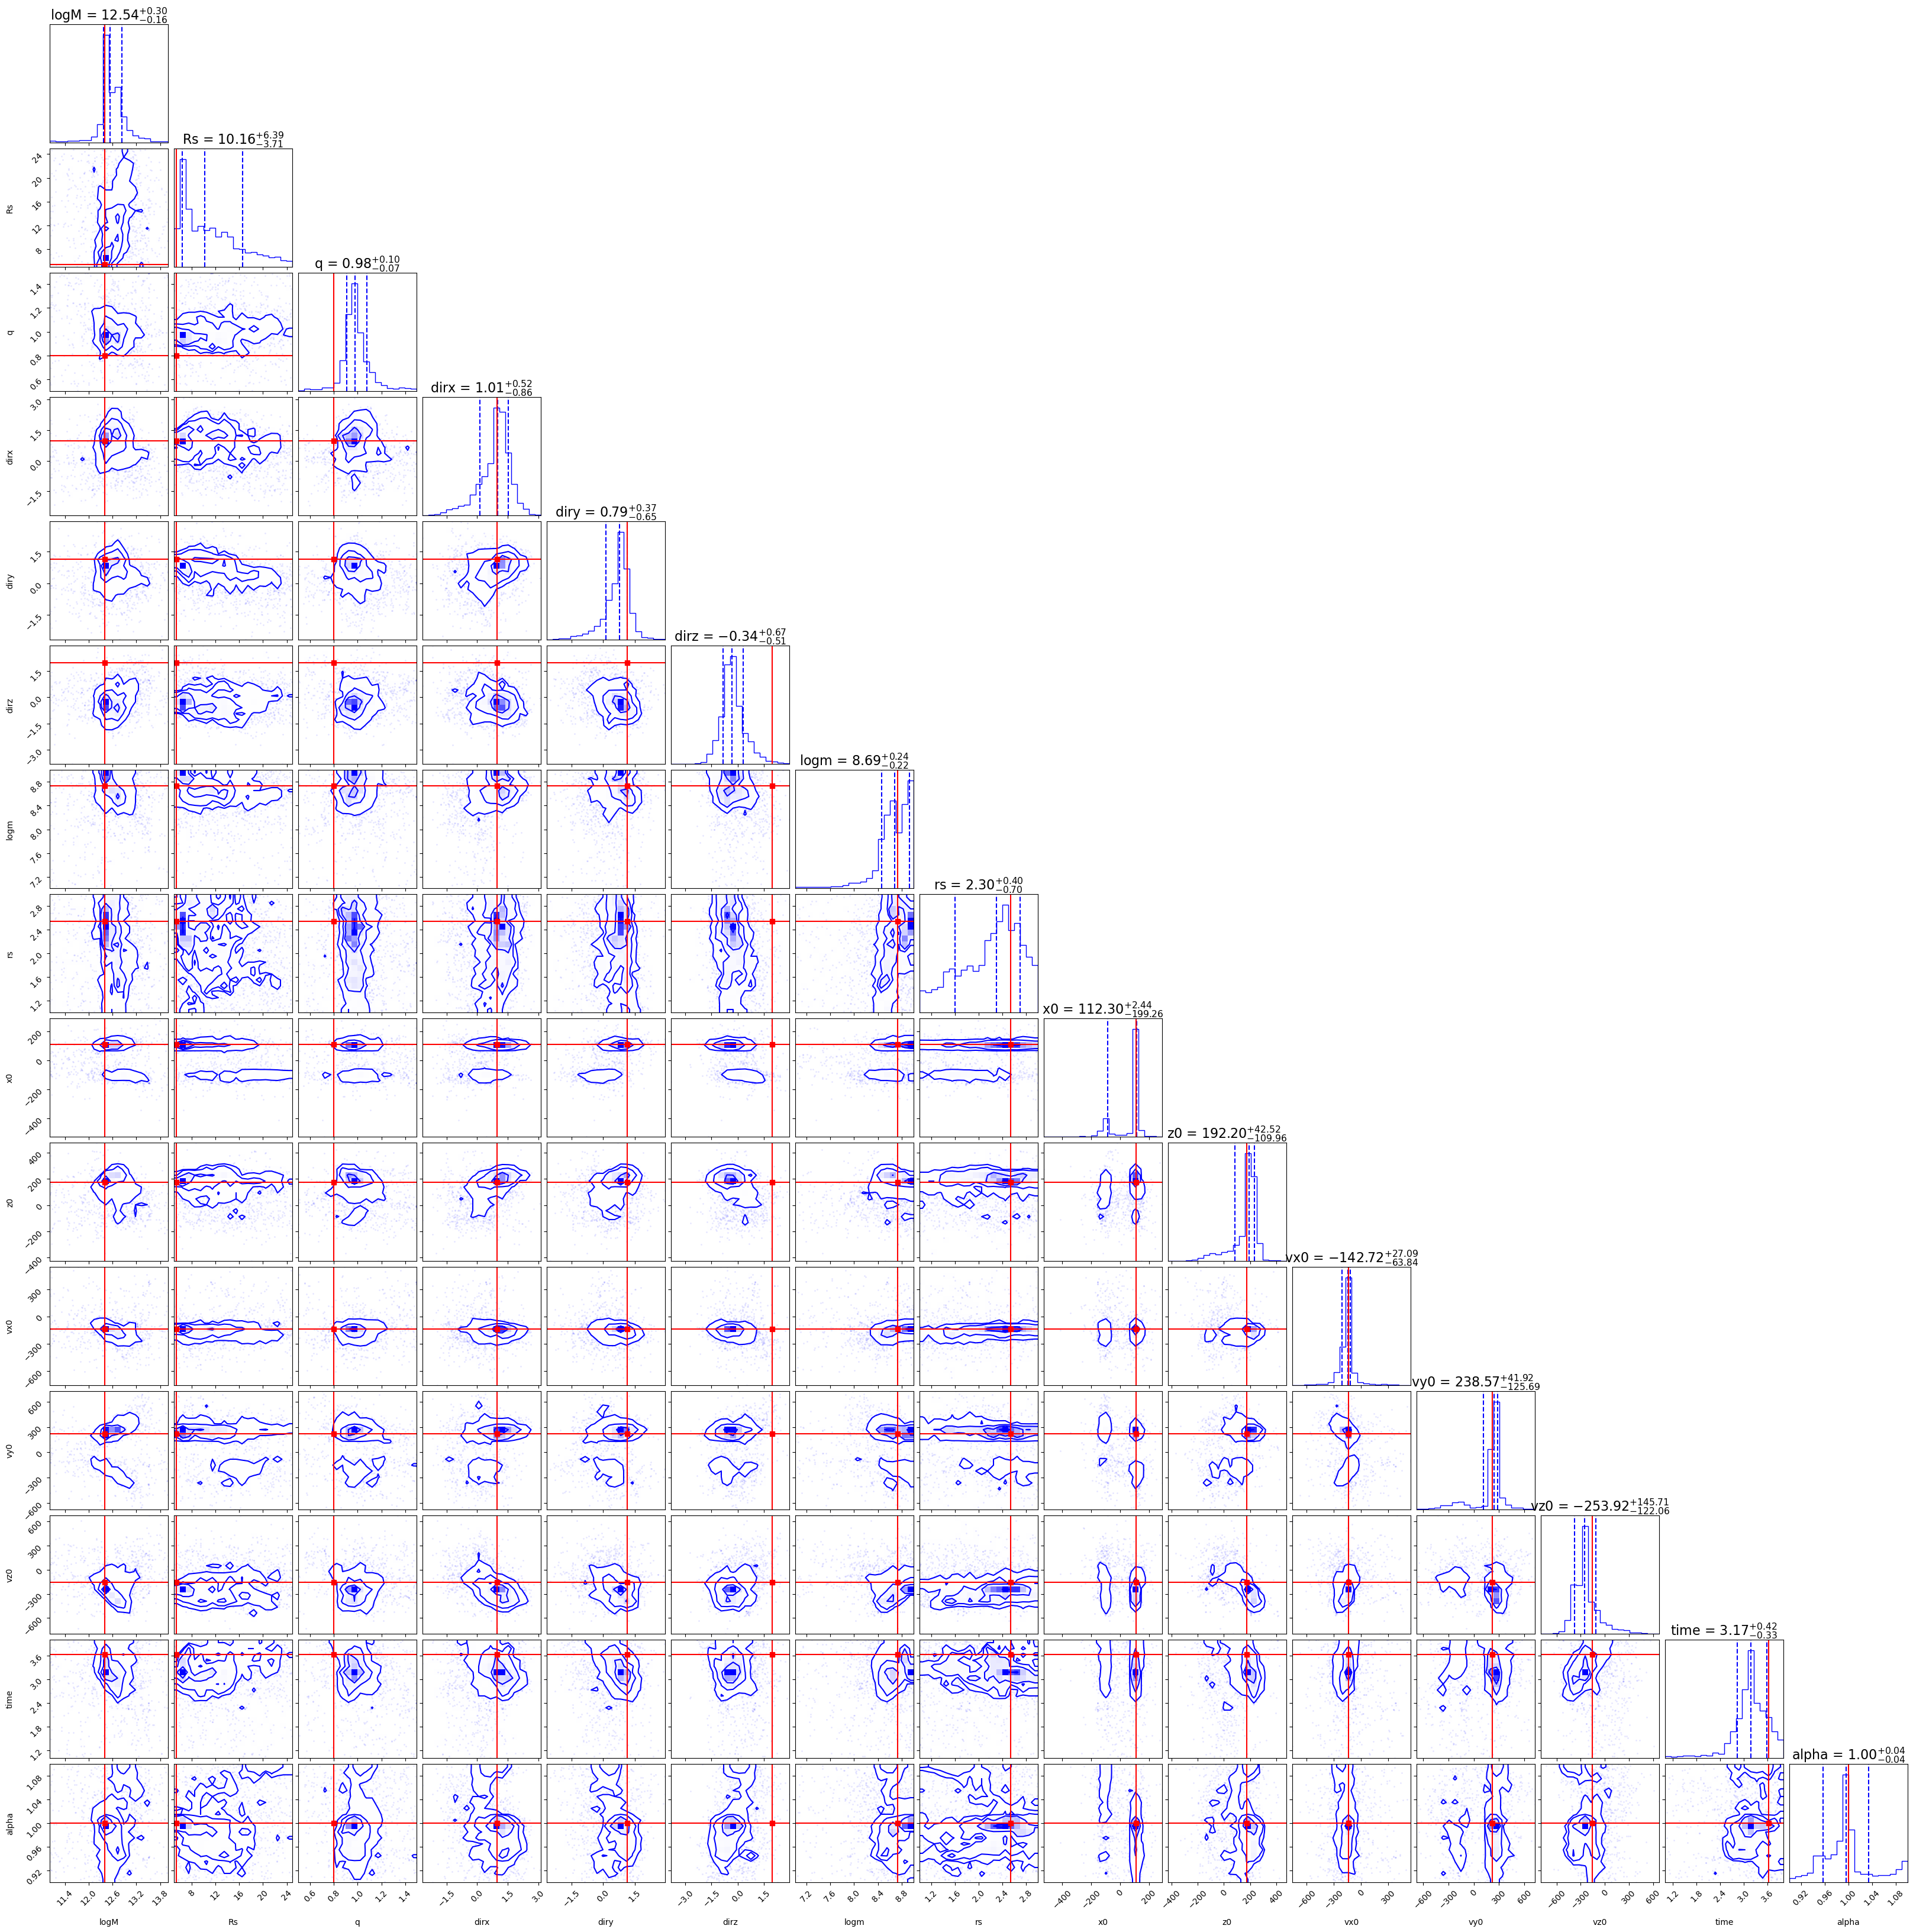

In [35]:
labels = ['logM', 'Rs', 'q', 'dirx', 'diry', 'dirz', 'logm', 'rs', 'x0', 'z0', 'vx0', 'vy0', 'vz0', 'time', 'alpha']
ground_truth = np.concatenate( [dict_data['params'], [1]])
figure = corner.corner(samps_100, 
            labels=labels,
            color='blue',
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True, 
            title_kwargs={"fontsize": 16},
            truths=ground_truth, 
            truth_color='red')
plt.savefig(f'plots/corner_q0.8_sig1_seed42_nlive100.pdf')

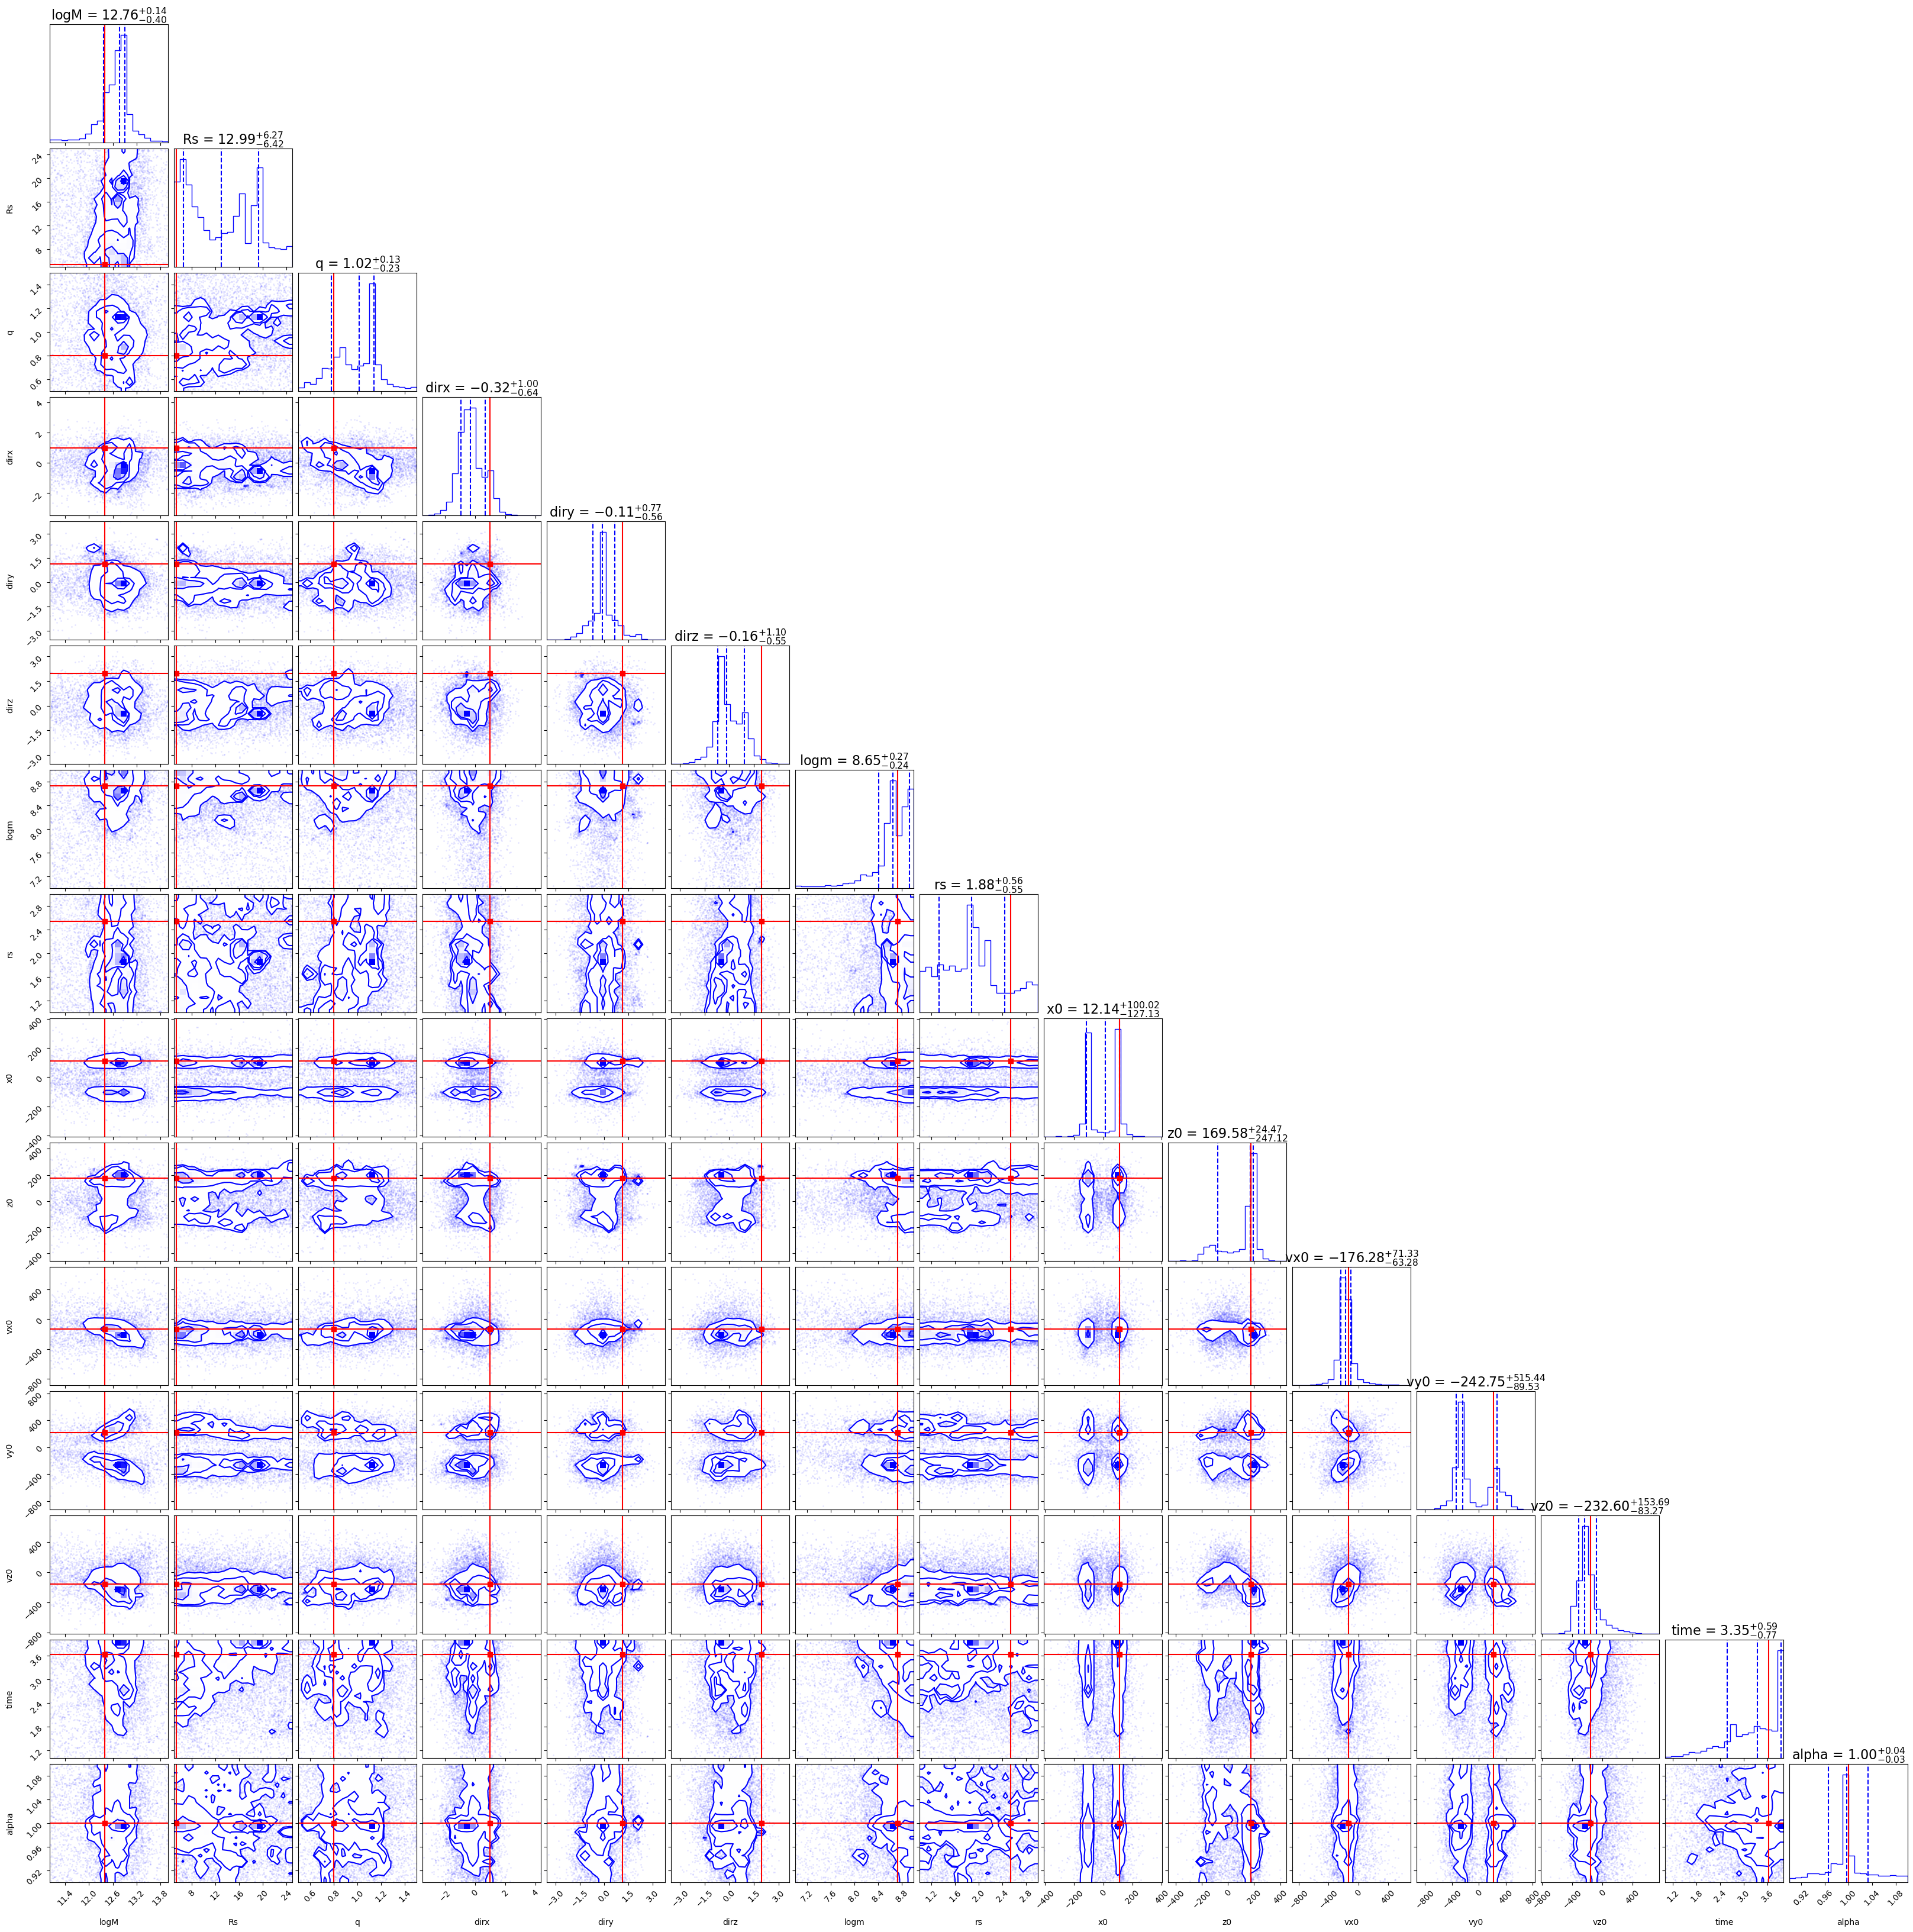

In [36]:
labels = ['logM', 'Rs', 'q', 'dirx', 'diry', 'dirz', 'logm', 'rs', 'x0', 'z0', 'vx0', 'vy0', 'vz0', 'time', 'alpha']
ground_truth = np.concatenate( [dict_data['params'], [1]])
figure = corner.corner(samps_500, 
            labels=labels,
            color='blue',
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True, 
            title_kwargs={"fontsize": 16},
            truths=ground_truth, 
            truth_color='red')
plt.savefig(f'plots/corner_q0.8_sig1_seed42_nlive500.pdf')

### Plot the best fits ###

In [11]:
logl_100, logl_500 = [], []
for i in tqdm(range(len(samps_500)), leave=True):
    if i < len(samps_100):
        logl_100.append(loglikelihood(samps_100[i], dict_data))
    logl_500.append(loglikelihood(samps_500[i], dict_data))
logl_100 = np.array(logl_100)
logl_500 = np.array(logl_500)

100%|██████████| 16000/16000 [36:52<00:00,  7.23it/s] 


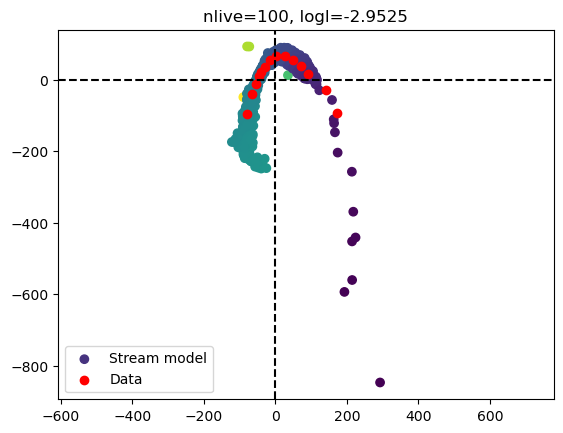

In [37]:
logM, Rs, q, dirx, diry, dirz, logm, rs, x0, z0, vx0, vy0, vz0, time, alpha = samps_100[np.argmax(logl_100)]
dirz = jnp.abs(dirz)
x0   = jnp.abs(x0)
y0   = 0.0
z0   = jnp.abs(z0)
vy0  = jnp.abs(vy0)
theta_stream, x_stream, y_stream, vz_stream, r_meds, w_meds, x_meds, y_meds, vz_meds = jax_stream_model(logM, Rs, q, dirx, diry, dirz, logm, rs, x0, y0, z0, vx0, vy0, vz0, time, alpha, tail=1, min_count=11)

plt.title(f'nlive=100, logl={np.max(logl_100):.4f}')
plt.scatter(x_stream, y_stream, c=theta_stream, label='Stream model')
plt.scatter(dict_data['x_meds'], dict_data['y_meds'], c='r', label='Data')
plt.legend(loc='best')
plt.axis('equal')
plt.axvline(0, c='k', ls='--')
plt.axhline(0, c='k', ls='--')
plt.savefig(f'plots/best_fit_q0.8_sig1_seed42_nlive100.pdf')

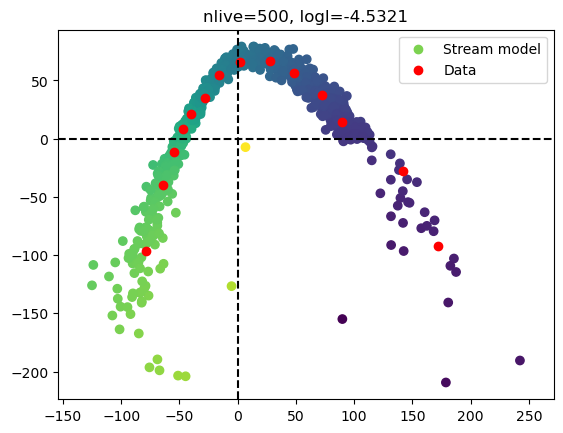

In [38]:
logM, Rs, q, dirx, diry, dirz, logm, rs, x0, z0, vx0, vy0, vz0, time, alpha = samps_500[np.argmax(logl_500)]
dirz = jnp.abs(dirz)
x0   = jnp.abs(x0)
y0   = 0.0
z0   = jnp.abs(z0)
vy0  = jnp.abs(vy0)
theta_stream, x_stream, y_stream, vz_stream, r_meds, w_meds, x_meds, y_meds, vz_meds = jax_stream_model(logM, Rs, q, dirx, diry, dirz, logm, rs, x0, y0, z0, vx0, vy0, vz0, time, alpha, tail=1, min_count=11)

plt.title(f'nlive=500, logl={np.max(logl_500):.4f}')
plt.scatter(x_stream, y_stream, c=theta_stream, label='Stream model')
plt.scatter(dict_data['x_meds'], dict_data['y_meds'], c='r', label='Data')
plt.legend(loc='best')
plt.axis('equal')
plt.axvline(0, c='k', ls='--')
plt.axhline(0, c='k', ls='--')
plt.savefig(f'plots/best_fit_q0.8_sig1_seed42_nlive500.pdf')

### Fit Orbits FAST ###

In [53]:
import time
import pickle
import scipy
from tqdm import tqdm

import numpy as np

import jax
import jax.numpy as jnp
import blackjax
from blackjax.ns.utils import finalise
print(jax.devices())

from data import get_data_orbit
from loglikelihood import loglikelihood_orbit

import dynesty
import dynesty.utils as dyut

from jax_dynesty_orbit import prior_transform

# Get data
q_true = 0.8
seed   = 42
sigma  = 1
nlive  = 5000
ndim   = 13
queue_size = 100
PATH_SAVE = f'.'

dict_data = get_data_orbit(q_true, seed, sigma)

dns = dynesty.DynamicNestedSampler(loglikelihood_orbit,
                        prior_transform,
                        ndim,
                        logl_args=(dict_data, ),
                        nlive=nlive,
                        sample='rslice')
dns.run_nested(n_effective=10000)

# Extract results
res = dns.results

[CpuDevice(id=0)]


231468it [22:31, 171.26it/s, batch: 0 | bound: 197 | nc: 1 | ncall: 22525839 | eff(%):  1.028 | loglstar:   -inf < -5.581 <    inf | logz: -48.979 +/-    nan | dlogz:  0.000 >  0.010]         


In [18]:
samples, weights = res.samples, np.exp(res.logwt - res.logz[-1])
samples_equal = dyut.resample_equal(samples, weights)
logl = res.logl

In [55]:
res   = dns.results
inds  = np.arange(len(res.samples))
inds  = dyut.resample_equal(inds, weights=np.exp(res.logwt - res.logz[-1]))
samps = res.samples[inds]
logl  = res.logl[inds]

dns_results = {
                'dns': dns,
                'samps': samps,
                'logl': logl,
                'logz': res.logz,
                'logzerr': res.logzerr,
            }

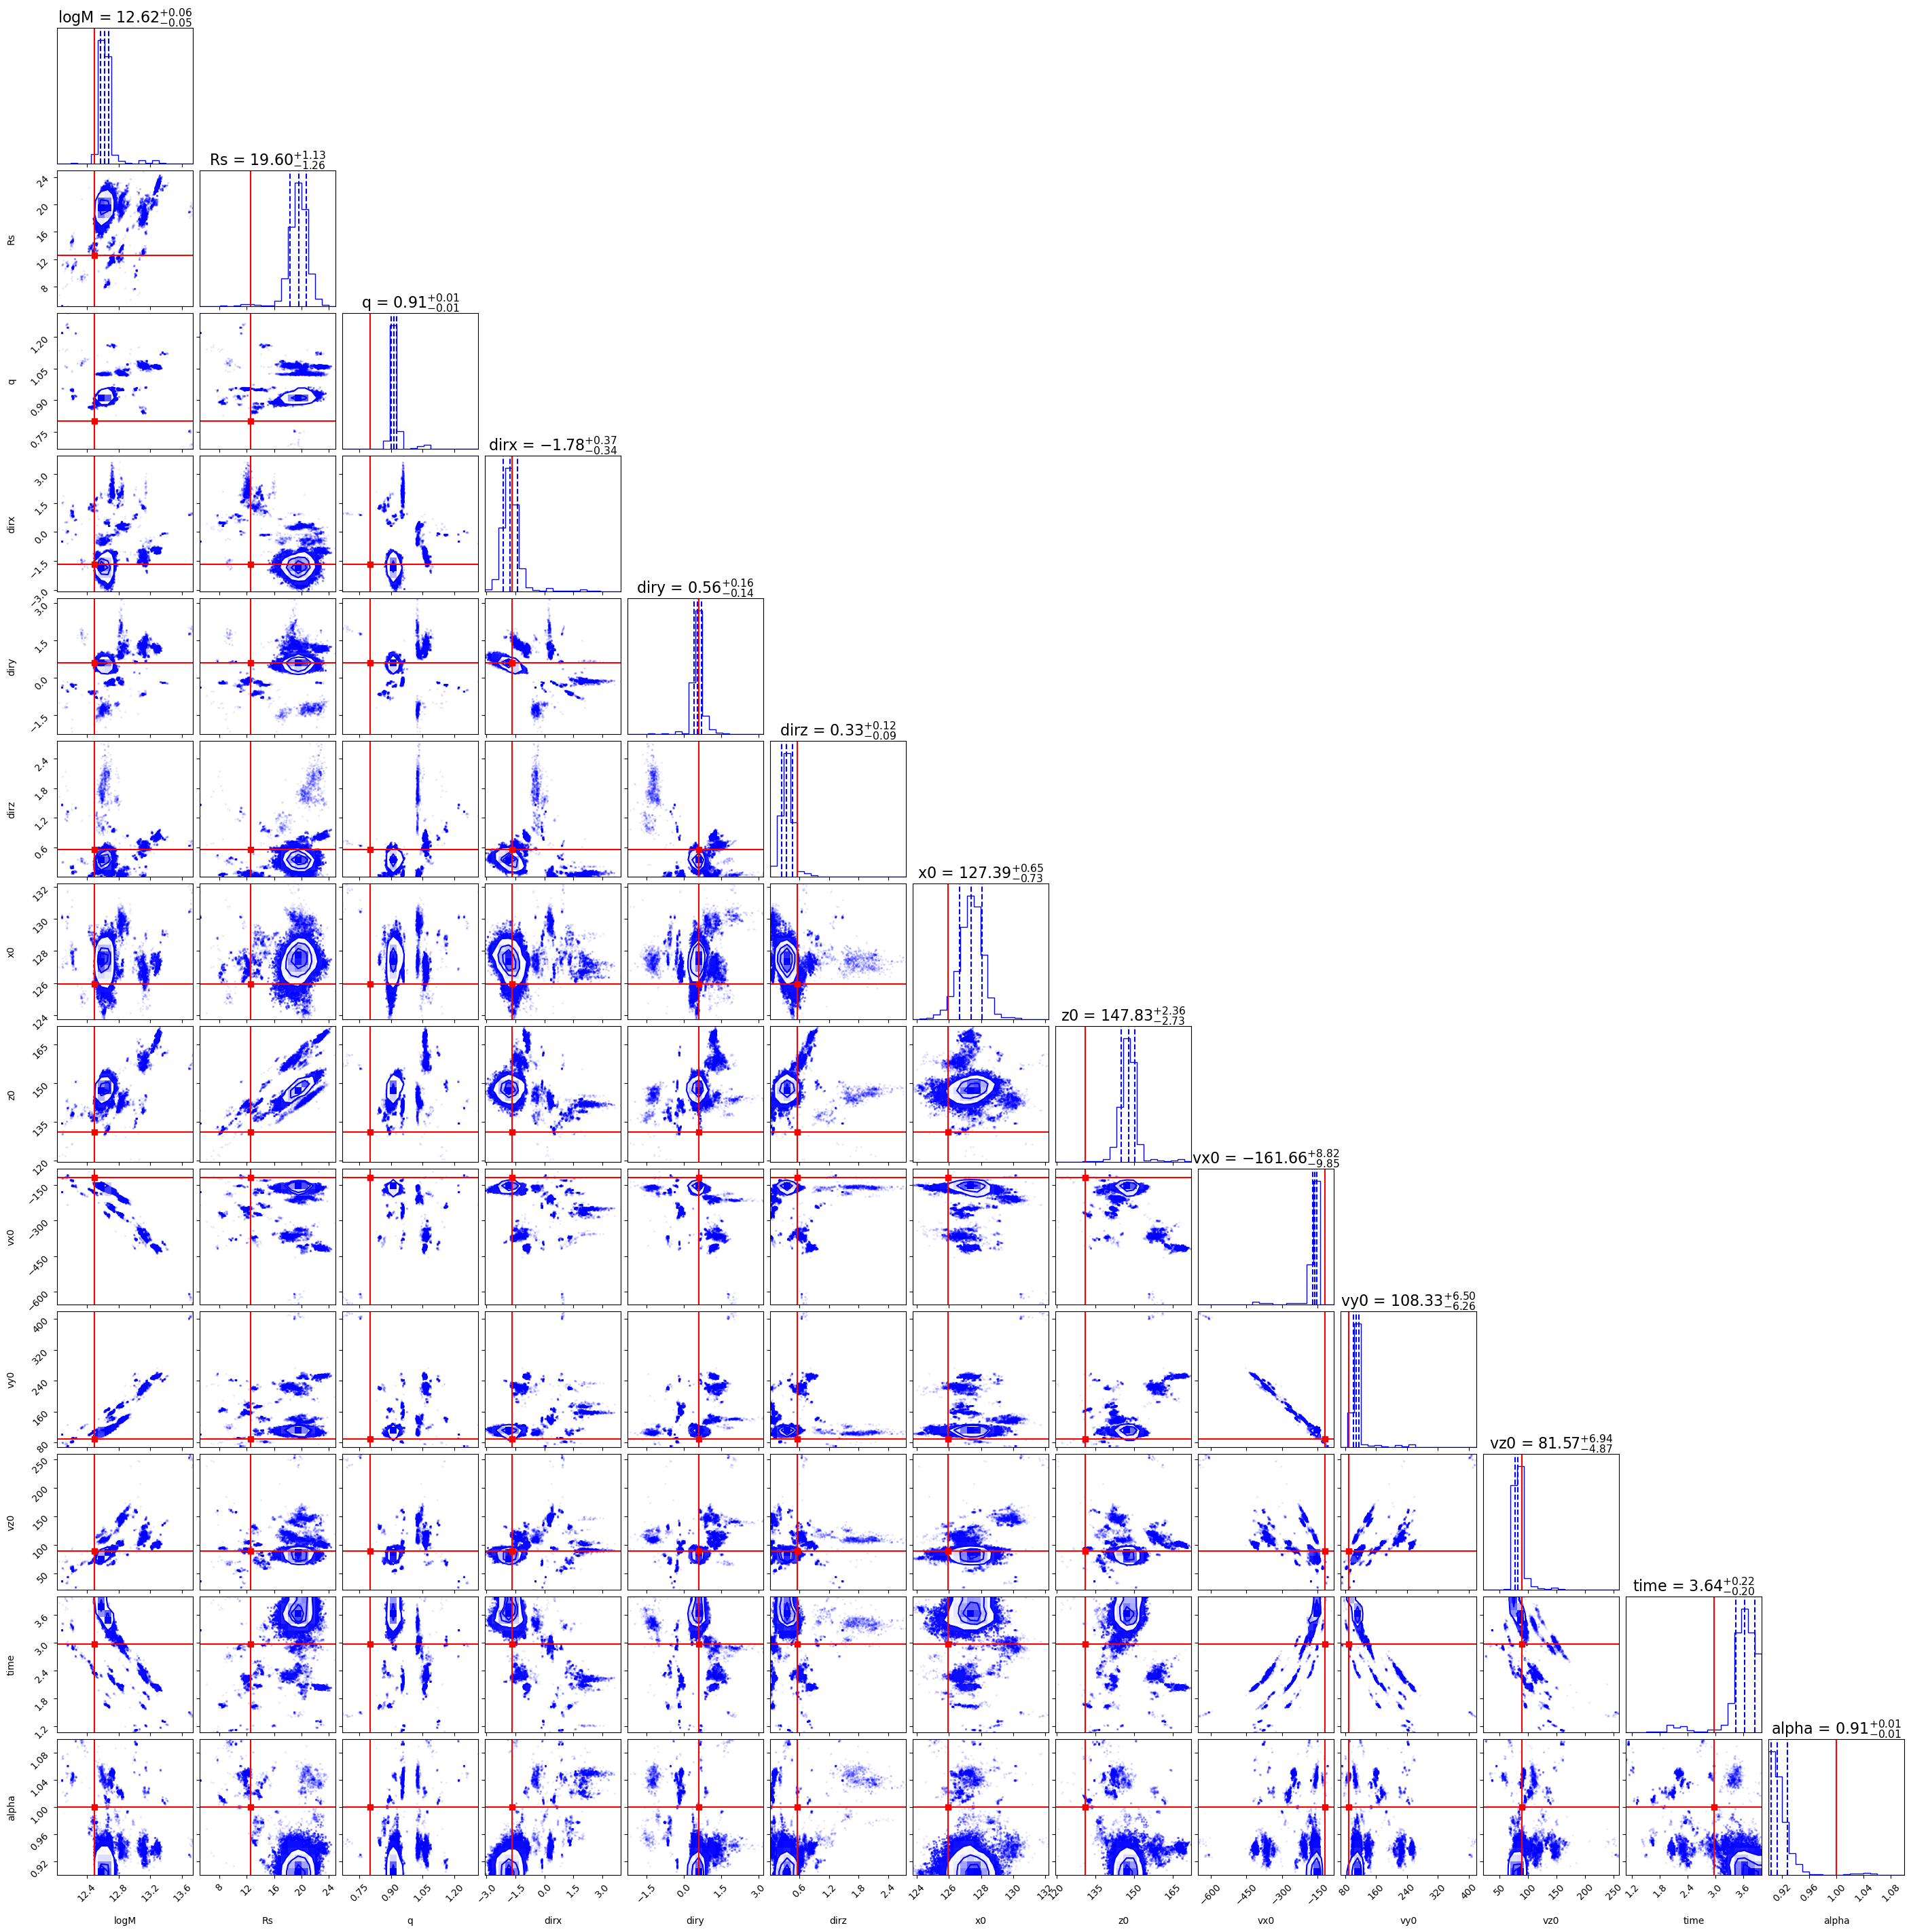

In [56]:
labels = ['logM', 'Rs', 'q', 'dirx', 'diry', 'dirz', 'x0', 'z0', 'vx0', 'vy0', 'vz0', 'time', 'alpha']
figure = corner.corner(dns_results['samps'], 
            labels=labels,
            color='blue',
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True, 
            title_kwargs={"fontsize": 16},
            truths=dict_data['params'], 
            truth_color='red')

In [40]:
best_params = dns_results['samps'][np.argmax(dns_results['logl'])]
logM, Rs, q, dirx, diry, dirz, x0, z0, vx0, vy0, vz0, time, alpha = best_params 

logM, Rs, q, dirx, diry, dirz, x0, z0, vx0, vy0, vz0, time = dict_data['params']
alpha = 1 

dirz = jnp.abs(dirz)
x0   = jnp.abs(x0)
z0   = jnp.abs(z0)
vy0  = jnp.abs(vy0)

r_data = dict_data['r_data']
w_data = dict_data['w_data']
r_err = dict_data['r_err']
w_err = dict_data['w_err']

y0 = 0.

theta_sat, x_sat, y_sat, vz_sat, r_meds, w_meds, x_meds, y_meds, vz_meds = jax_stream_orbit(logM, Rs, q, dirx, diry, dirz, x0, y0, z0, vx0, vy0, vz0, time, alpha)

In [50]:
loglikelihood_orbit(dns_results['samps'][np.argmax(dns_results['logl'])], dict_data)

Array(-4.49170564, dtype=float64, weak_type=True)

In [52]:
loglikelihood_orbit(dict_data['params'], dict_data)

Array(-5.91416745, dtype=float64, weak_type=True)

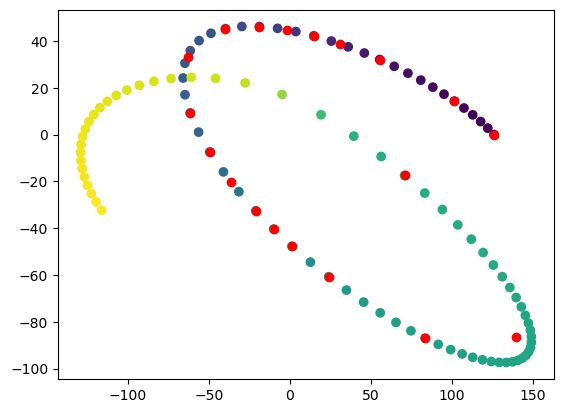

In [41]:
plt.scatter(x_sat, y_sat, c=theta_sat, label='Stream model')
plt.scatter(dict_data['x_meds'], dict_data['y_meds'], c='r', label='Data')

### Fit Streams FAST ###

In [59]:
import time
import pickle
import scipy

import numpy as np

import jax
print(jax.devices())

from data import get_data_stream
from loglikelihood import loglikelihood_stream

import dynesty
import dynesty.utils as dyut

def prior_transform(p):
    #ndim = 13
    logM, Rs, q, dirx, diry, dirz, \
    logm, rs, \
    x0, z0, vx0, vy0, vz0, \
    t0, a0 = p

    logM1  = (11 + 3*logM)
    Rs1    = (5 + 20*Rs)
    q1     = 0.5 + q
    dirx1, diry1, dirz1 = [
        scipy.special.ndtri(_) for _ in [dirx, diry, 0.5 + dirz/2]
    ]

    logm1 = (7 + 2*logm) 
    rs1   = (1 + 2*rs)

    x1, z1 = [
        scipy.special.ndtri(_) * 150 for _ in [0.5 + x0/2, 0.5 + z0/2]
    ]

    vx1, vy1, vz1 = [
        scipy.special.ndtri(_) * 250 for _ in [vx0, 0.5 + vy0/2, vz0]
    ]

    t1 = 1 + 3*t0

    a1 = 0.9 + 0.2*a0

    return [logM1, Rs1, q1, dirx1, diry1, dirz1, 
            logm1, rs1,
            x1, z1, vx1, vy1, vz1,
            t1, a1]

[CpuDevice(id=0)]


Time taken: 0.19 seconds


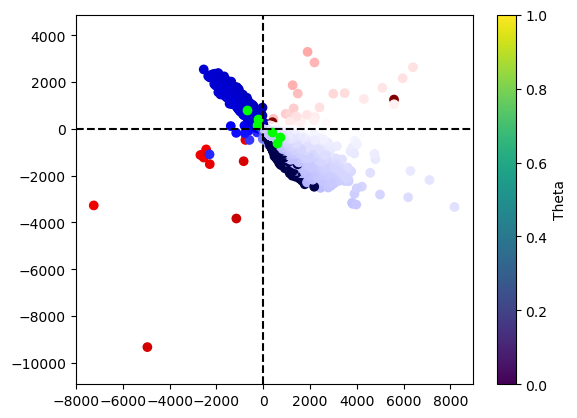

In [158]:
p = np.random.uniform(size=15)
params = prior_transform(p)
logM, Rs, q, dirx, diry, dirz, logm, rs, x0, z0, vx0, vy0, vz0, t0, a0 = params
y0 = 0.

a = time.time()
theta_stream, x_stream, y_stream, vz_stream, r_meds, w_meds, x_meds, y_meds, vz_meds = jax_stream_model(logM, Rs, q, dirx, diry, dirz, logm, rs, x0, y0,  z0, vx0, vy0, vz0, t0, a0, tail=0, min_count=101)
b = time.time()
print(f'Time taken: {b - a:.2f} seconds')

plt.scatter(x_stream, y_stream, c=theta_stream, label='Stream model', cmap='seismic', vmin=-2*np.pi, vmax=2*np.pi)
plt.scatter(x_meds, y_meds, c='lime', label='Medians')
plt.colorbar(label='Theta')
plt.axis('equal')
plt.axvline(0, color='k', ls='--')
plt.axhline(0, color='k', ls='--')

In [118]:
theta_stream.shape

(9999,)

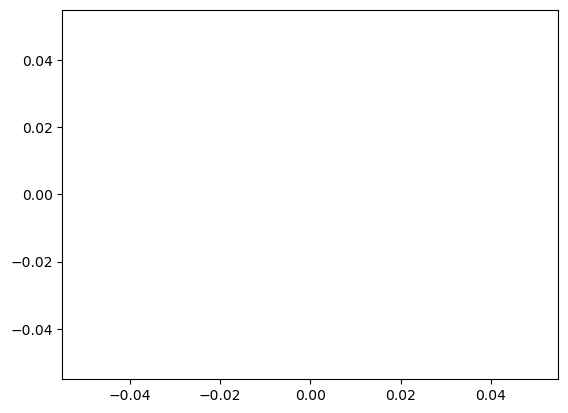